# Task 1 & Task 2 (EDA portion): Brent Oil Price — Exploratory Data Analysis

This notebook covers:
1. Data loading and cleaning
2. Raw price trend analysis
3. Log-return calculation and stationarity testing
4. Volatility clustering
5. Initial visual cross-reference with key events

The Bayesian change point model (PyMC) is developed separately in `notebooks/change_point_model.ipynb` (Task 2 core deliverable) once this EDA establishes the modeling rationale.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller

from scripts.data_loader import load_brent_prices

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load and Inspect Data

In [2]:
df = load_brent_prices()
print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Rows: 9011
Date range: 1987-05-20 to 2022-11-14


,Price,LogPrice,LogReturn
Date,,,
1987-05-20,18.63,2.924773,NaN
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612


In [3]:
df.describe()

,Price,LogPrice,LogReturn
count,9011.000000,9011.000000,9010.000000
mean,48.420782,3.638729,0.000179
std,32.860110,0.707122,0.025532
min,9.100000,2.208274,-0.643699
25%,19.050000,2.947067,-0.011154
50%,38.570000,3.652475,0.000402
75%,70.090000,4.249780,0.012127
max,143.950000,4.969466,0.412023


In [4]:
# Check for missing values / gaps
print("Missing values:\n", df.isna().sum())
print(f"\nAny non-positive prices? {(df['Price'] <= 0).any()}")

Missing values:
 Price        0
LogPrice     0
LogReturn    1
dtype: int64

Any non-positive prices? False


## 2. Raw Price Series — Trend Analysis

Plotting the raw price lets us visually locate major bull/bear regimes and
obvious shock events before any formal modeling.

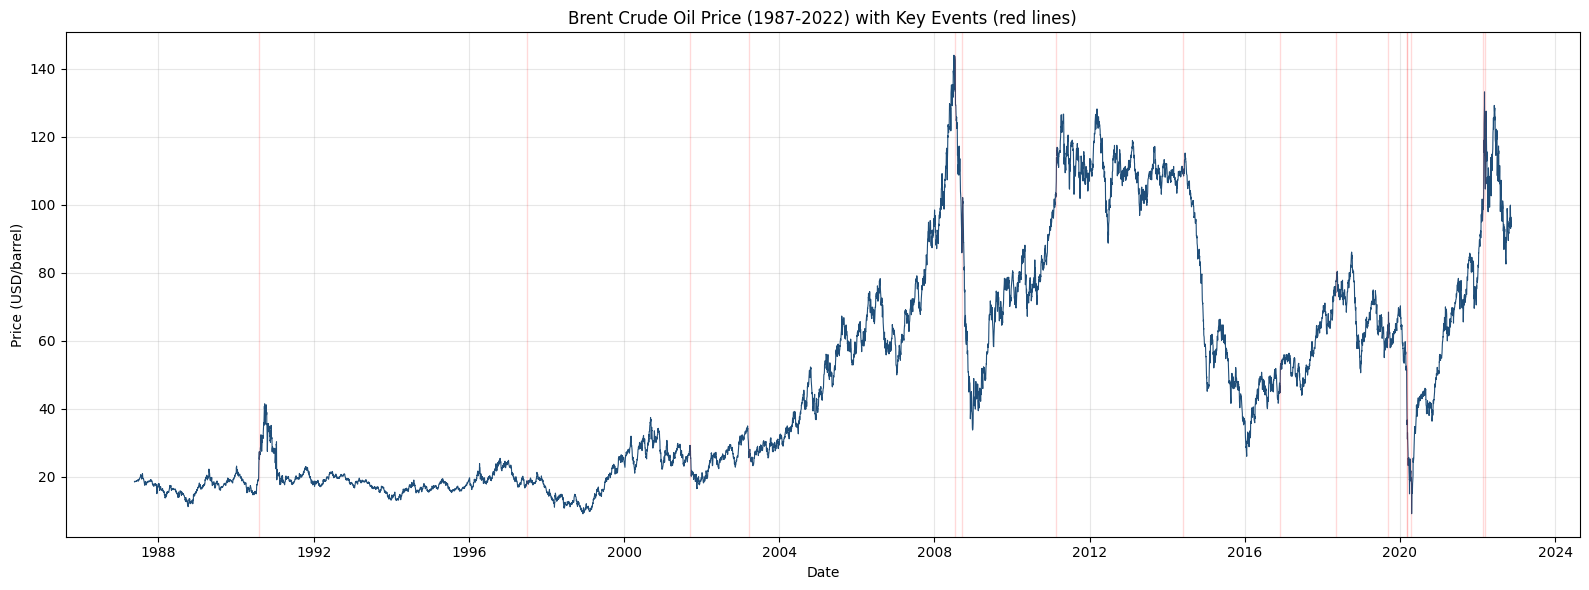

In [5]:
events = pd.read_csv('../data/key_events.csv', parse_dates=['start_date'])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['Price'], linewidth=0.8, color='#1f4e79')
for _, row in events.iterrows():
    ax.axvline(row['start_date'], color='red', alpha=0.15, linewidth=1)
ax.set_title('Brent Crude Oil Price (1987-2022) with Key Events (red lines)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
plt.tight_layout()
plt.savefig('../docs/raw_price_series.png', dpi=120)
plt.show()

**Observations:**
- Prices are largely range-bound and low (under $25) through the 1990s.
- A strong upward trend begins in the early 2000s, peaking in mid-2008 near
  $147/barrel, immediately followed by the sharpest crash in the series
  (2008 Global Financial Crisis).
- A second major collapse occurs in 2014-2016 (shale supply glut / OPEC
  inaction).
- The most extreme, fastest single collapse is in early 2020 (COVID-19 demand
  shock + Saudi-Russia price war).
- 2022 shows a sharp rally coinciding with Russia's invasion of Ukraine.

The series is visibly **non-stationary**: it trends over long periods and its
volatility is clearly not constant (large swings cluster around 2008, 2014-16,
and 2020). This directly motivates working with **log returns** instead of
raw price levels for the statistical model.

## 3. Stationarity Testing — Price Level

In [6]:
result = adfuller(df['Price'].dropna())
print('ADF Statistic: %.4f' % result[0])
print('p-value: %.4f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

if result[1] > 0.05:
    print('\n=> Fail to reject H0: the raw price series has a unit root (non-stationary).')
else:
    print('\n=> Reject H0: the raw price series appears stationary.')

ADF Statistic: -1.9939
p-value: 0.2893
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

=> Fail to reject H0: the raw price series has a unit root (non-stationary).


## 4. Log Returns — Calculation & Stationarity

Log returns are computed as `r_t = log(P_t) - log(P_{t-1})`. This is the
standard transform for price series because it:
- Removes the long-run trend, focusing on relative day-to-day change
- Tends to stabilize variance somewhat (though volatility clustering remains)
- Makes cross-period comparisons meaningful (a $5 move means very different
  things at a $20 price level vs. a $120 price level)

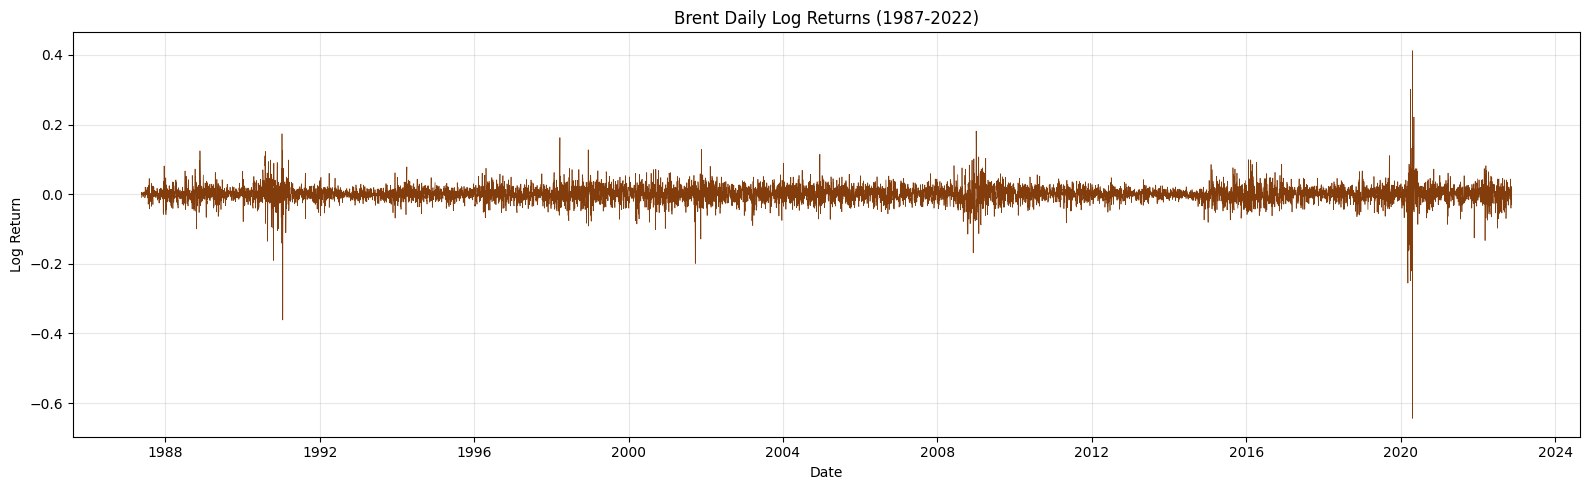

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['LogReturn'], linewidth=0.5, color='#833C0C')
ax.set_title('Brent Daily Log Returns (1987-2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
plt.tight_layout()
plt.savefig('../docs/log_returns.png', dpi=120)
plt.show()

**Observations — Volatility Clustering:** large log-return swings are not
spread evenly across history — they cluster tightly around 2008-09, late
2014-2016, and especially March-April 2020, exactly the periods of major
identified shocks. Calm periods (e.g., most of the 1990s and mid-2000s) show
visibly tighter bands. This clustering pattern (large changes followed by
more large changes, small by small) is a hallmark of financial time series
and is one of the key properties a robust model needs to account for —
it's part of the motivation for a *change point* framing (distinct volatility
regimes) rather than assuming one constant variance for the whole history.

In [8]:
result_lr = adfuller(df['LogReturn'].dropna())
print('ADF Statistic: %.4f' % result_lr[0])
print('p-value: %.6f' % result_lr[1])
print('Critical Values:')
for key, value in result_lr[4].items():
    print(f'   {key}: {value:.4f}')

if result_lr[1] > 0.05:
    print('\n=> Fail to reject H0: log returns are non-stationary.')
else:
    print('\n=> Reject H0: log returns are stationary, consistent with typical financial return series.')

ADF Statistic: -16.4271
p-value: 0.000000
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

=> Reject H0: log returns are stationary, consistent with typical financial return series.


## 5. Rolling Volatility

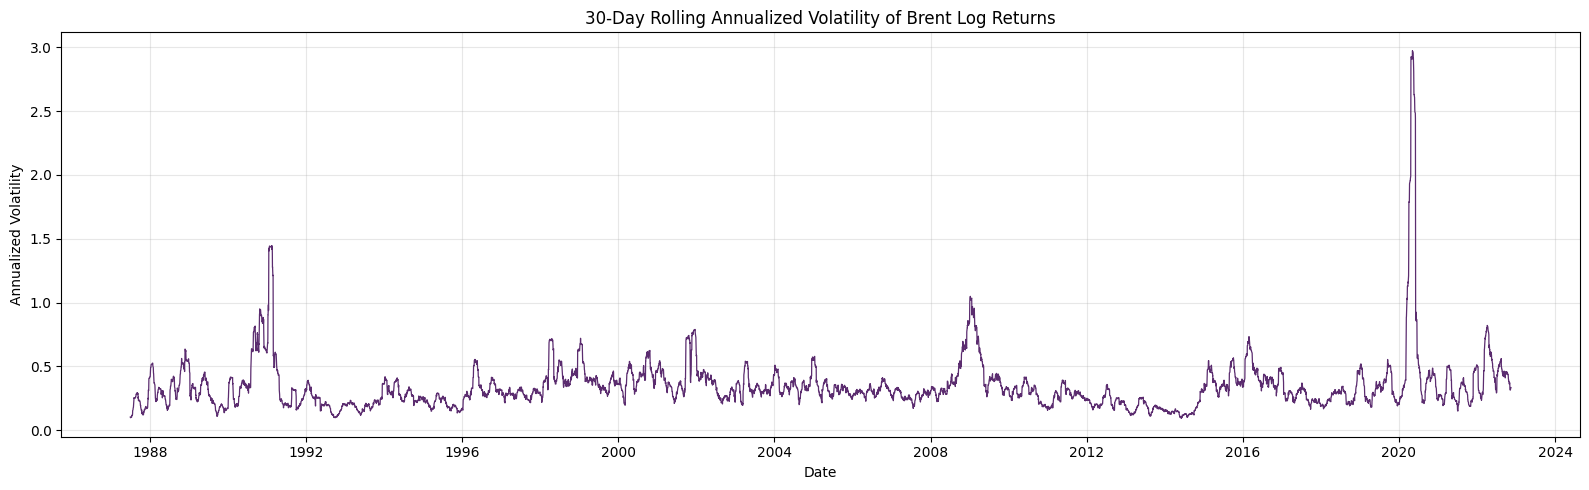

In [9]:
rolling_vol = df['LogReturn'].rolling(window=30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, rolling_vol, color='#5B2C6F', linewidth=0.9)
ax.set_title('30-Day Rolling Annualized Volatility of Brent Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
plt.tight_layout()
plt.savefig('../docs/rolling_volatility.png', dpi=120)
plt.show()

**Observation:** volatility spikes sharply around 2008-09, 2014-16, and peaks
at its highest level in the dataset during March-April 2020 (COVID + price
war), consistent with the raw price and log-return plots above.

## 6. How These Properties Inform Modeling Choices

- **Non-stationary price level** → we should not model the raw price
  directly with a stationary likelihood; either model log returns, or model
  price levels but explicitly allow the mean/variance to shift at change
  points (which is exactly what the Bayesian change point model does).
- **Volatility clustering** → a single global variance is a poor
  assumption across the full 35-year history. This motivates either (a)
  allowing variance, not just the mean, to shift at the change point(s) in
  the PyMC model, or (b) restricting a single change-point model to a
  shorter window around a specific event and running multiple such analyses.
- **Multiple visually obvious shocks** (2008, 2014-16, 2020, 2022) suggest
  that a **single** change point is likely too simple for the *entire*
  history; a multiple-change-point extension (or per-event windowed
  analysis) is planned as part of Task 2's core deliverable.

## 7. Purpose of Change Point Models (Task 1 requirement)

A change point model formalizes the search for the point(s) in time where
the statistical properties of a series (its mean, variance, or both) shift
abruptly — a *structural break*. Rather than eyeballing the plots above, a
Bayesian change point model:

- Places a prior over **where** the break could occur (`tau`), treating it as
  an unknown parameter to be inferred rather than assumed.
- Estimates the regime parameters before and after `tau` jointly with `tau`
  itself, giving a full posterior — not just a point estimate — over both
  *when* the change happened and *how large* it was.
- Naturally quantifies uncertainty: a narrow posterior on `tau` means the
  data strongly pins down one specific date; a wide/multi-modal posterior
  means the evidence for a break at any single date is weak or the series
  contains more than one break.

**Expected outputs** of the analysis: (1) a posterior distribution over the
change point date(s) `tau`, (2) posterior distributions for the "before" and
"after" parameters (e.g., mean price/return, volatility), and (3) derived
quantitative impact statements (e.g., "mean log price shifted from A to B,
a Z% change, with probability P based on the posterior").

**Limitations** of the output: the model only tells us a statistical
property changed and by how much — associating *that* change with a
specific real-world cause is an interpretive step done afterward by
comparing the estimated date to the events dataset (see
`docs/assumptions_and_limitations.md` for the correlation-vs-causation
discussion).

## 8. Save Cleaned Data for Downstream Use

In [10]:
df.to_csv('../data/brent_prices_cleaned.csv')
print('Saved cleaned dataset to data/brent_prices_cleaned.csv')
print(df.shape)

Saved cleaned dataset to data/brent_prices_cleaned.csv
(9011, 3)
